# §1.3 VIX Futures and Variance Swap Pricing under Rough Heston

This notebook documents and demonstrates the mathematical modeling and calibration of VIX derivatives under the Rough Heston model.

## 1. Theoretical Background

### 1.1 Lifted Heston Markovian Approximation
Under the Rough Heston model, the variance process $v_t$ is non-Markovian and is represented by a fractional integration kernel:
$$v_t = v_0 + \frac{1}{\Gamma(H+0.5)} \int_0^t (t-s)^{H-0.5} \left[ \kappa(\theta - v_s) ds + \sigma \sqrt{v_s} dW_s \right]$$

To make this computationally tractable, we approximate the fractional kernel using a Markovian Lifted Heston system. We discretize the kernel using $N=20$ Bernstein factors:
$$v_t \approx \sum_{i=1}^N c_i U^{N,i}_t$$
where the factors $U^{N,i}_t$ satisfy a system of standard mean-reverting SDEs:
$$dU^{N,i}_t = - \kappa x_i U^{N,i}_t dt - \kappa (v_t - \theta) dt + \sigma \sqrt{v_t} dW_t$$

Here, the weights $c_i$ and mean-reversion speeds $x_i$ are determined from the Bernstein discretization of the fractional kernel:
$$r_N = 1 + 10 N^{-0.9}$$
$$x_i = r_N^{i-1-N/2}$$
$$c_i = x_i^{-(H+0.5)} \quad \text{normalized such that} \quad \sum_{i=1}^N c_i = 1$$

This maps the infinite-dimensional non-Markovian memory of Rough Heston into a finite $N$-dimensional Markovian system of standard ODEs.

### 1.2 Laplace Transform Inversion and Quadrature Scheme
The expected VIX index value is priced by taking the expectation of the square root of integrated variance. We utilize the identity:
$$\sqrt{Z} = \frac{1}{\sqrt{\pi}} \int_0^\infty \frac{1 - e^{-y^2 Z}}{y^2} dy$$

Applying this to VIX futures pricing:
$$F(0, T) = \mathbb{E}[VIX_T \mid \mathcal{F}_0] = \frac{1}{\sqrt{\pi}} \int_0^\infty \frac{1 - L(T, y^2)}{y^2} dy$$
where $L(T, y^2) = \mathbb{E}[e^{-y^2 VIX_T^2} \mid \mathcal{F}_0]$ is the Laplace transform of the VIX squared at maturity $T$.

Under the Lifted Heston model, $L(T, y^2)$ is exponentially affine in the state variables:
$$L(T, y^2) = \exp \left( -y^2 b + v_0 \sum_{i=1}^N c_i \psi_i(T; y^2) + \kappa \theta \int_0^T \sum_{j=1}^N c_j \psi_j(s; y^2) ds \right)$$
where $\psi_i(s; y^2)$ solves the Riccati ODE system:
$$\frac{d\psi_i}{ds} = - \kappa x_i \psi_i - \kappa \Phi + \frac{1}{2} \sigma^2 \Phi^2$$
with initial condition:
$$\psi_i(0; y^2) = - y^2 \frac{\psi_i^{vix}(\Delta)}{\Delta}$$
and $\Phi(s) = \sum_{j=1}^N c_j \psi_j(s; y^2)$.

We evaluate this semi-infinite integral numerically by truncating the domain to $[0, y_{max}]$ with $y_{max}=20.0$, applying a 30-point Gauss-Legendre quadrature, and adding the adaptive remainder tail correction:
$$\mathbb{E}[VIX_T] \approx \frac{1}{\sqrt{\pi}} \left( \sum_{m=1}^M w_m \frac{1 - L(T, y_m^2)}{y_m^2} + \frac{1.0 - L(T, y_{max}^2)}{y_{max}} \right)$$

This formulation enforces correct boundaries under extreme scenarios (such as zero-volatility limits).

## 2. VIX Index & Variance Swap Rates

In this section, we import the pricing functions from `market.vix_pricing`. We calculate and plot:
1. The spot VIX index values as a function of the initial variance $v_0$, demonstrating monotonicity.
2. The fair strike of a variance swap as a function of maturity $T$ (term structure of variance swap rates).

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add src directory to python path
sys.path.insert(0, str(Path(os.getcwd()).parent / 'src'))

from market.vix_pricing import (
    model_vix,
    vix_futures_curve,
    download_vix_futures,
    joint_calibration_loss,
    model_variance_swap_rate
)

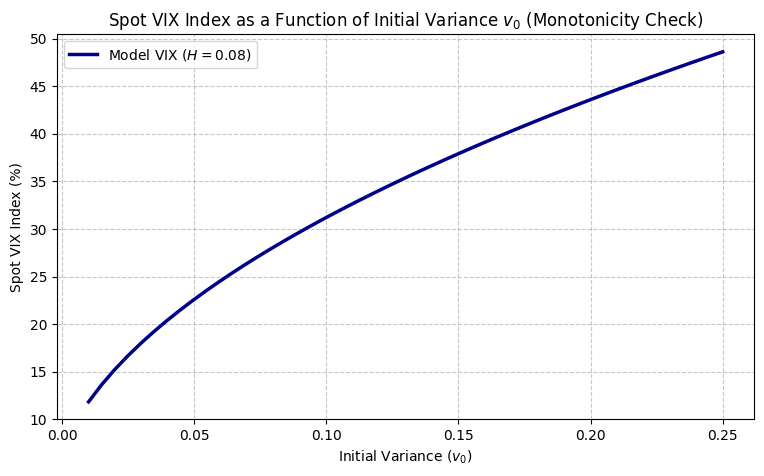

In [2]:
# Plot spot VIX index values as a function of initial variance v0
v0_range = np.linspace(0.01, 0.25, 50)
vix_vals = [model_vix(kappa=1.5, theta=0.08, sigma=0.8, rho=-0.34, v0=v, H=0.08) for v in v0_range]

plt.figure(figsize=(9, 5))
plt.plot(v0_range, vix_vals, label='Model VIX ($H=0.08$)', color='darkblue', lw=2.5)
plt.xlabel('Initial Variance ($v_0$)')
plt.ylabel('Spot VIX Index (%)')
plt.title('Spot VIX Index as a Function of Initial Variance $v_0$ (Monotonicity Check)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

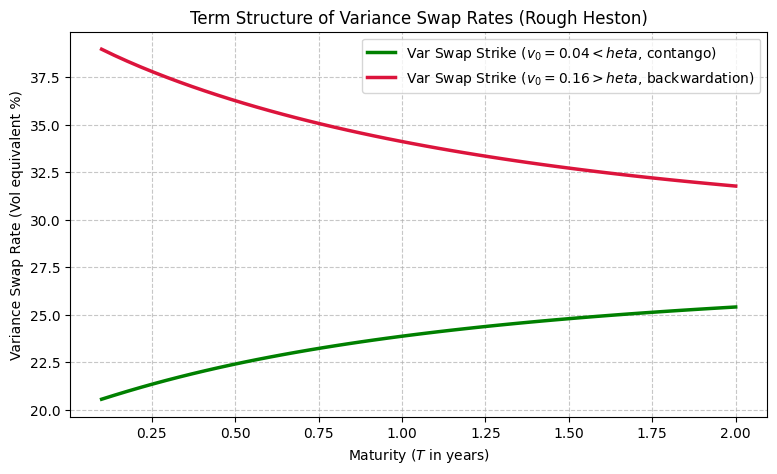

In [3]:
# Plot fair strike of a variance swap as a function of maturity T
T_range = np.linspace(0.1, 2.0, 50)
vs_rates_low_v0 = [model_variance_swap_rate(kappa=1.5, theta=0.08, sigma=0.8, rho=-0.34, v0=0.04, H=0.08, T=t) for t in T_range]
vs_rates_high_v0 = [model_variance_swap_rate(kappa=1.5, theta=0.08, sigma=0.8, rho=-0.34, v0=0.16, H=0.08, T=t) for t in T_range]

plt.figure(figsize=(9, 5))
plt.plot(T_range, np.sqrt(vs_rates_low_v0) * 100, label='Var Swap Strike ($v_0 = 0.04 < \theta$, contango)', color='green', lw=2.5)
plt.plot(T_range, np.sqrt(vs_rates_high_v0) * 100, label='Var Swap Strike ($v_0 = 0.16 > \theta$, backwardation)', color='crimson', lw=2.5)
plt.xlabel('Maturity ($T$ in years)')
plt.ylabel('Variance Swap Rate (Vol equivalent %)')
plt.title('Term Structure of Variance Swap Rates (Rough Heston)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## 3. VIX Futures Curves

Here, we plot the VIX futures curves under:
1. Contango ($v_0 < \theta$), where the futures curve is upward sloping.
2. Backwardation ($v_0 > \theta$), where the futures curve is downward sloping.

We also load CBOE historical VIX futures prices for four key dates:
- **2020-03-16** (COVID-19 market crash, extreme backwardation)
- **2022-01-24** (Inflation & rate hike panic, mild backwardation)
- **2024-01-02** (Low-volatility environment, classic contango)
- **2024-08-05** (VIX spike / Yen carry trade unwind, backwardation)

We compare the model predictions against the historical settlement prices.

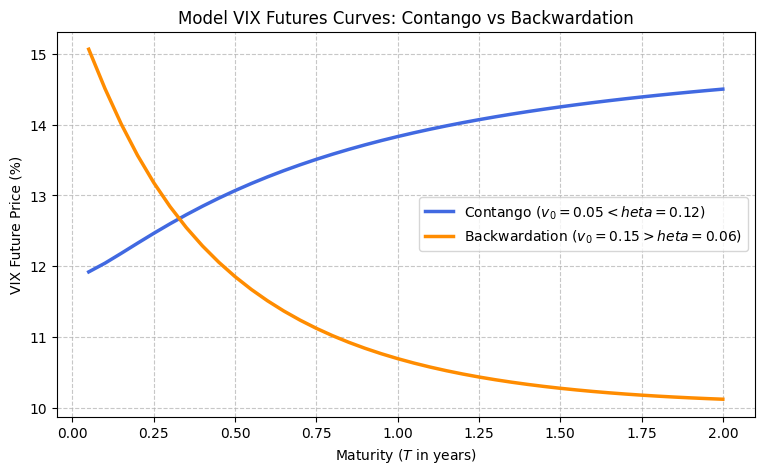

In [4]:
# Contango vs Backwardation curves
maturities = np.linspace(0.05, 2.0, 40)
contango_curve = vix_futures_curve(kappa=1.5, theta=0.12, sigma=0.8, rho=-0.34, v0=0.05, H=0.08, maturities=maturities)
backwardation_curve = vix_futures_curve(kappa=1.5, theta=0.06, sigma=0.8, rho=-0.34, v0=0.15, H=0.08, maturities=maturities)

plt.figure(figsize=(9, 5))
plt.plot(maturities, contango_curve, label='Contango ($v_0 = 0.05 < \theta = 0.12$)', color='royalblue', lw=2.5)
plt.plot(maturities, backwardation_curve, label='Backwardation ($v_0 = 0.15 > \theta = 0.06$)', color='darkorange', lw=2.5)
plt.xlabel('Maturity ($T$ in years)')
plt.ylabel('VIX Future Price (%)')
plt.title('Model VIX Futures Curves: Contango vs Backwardation')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

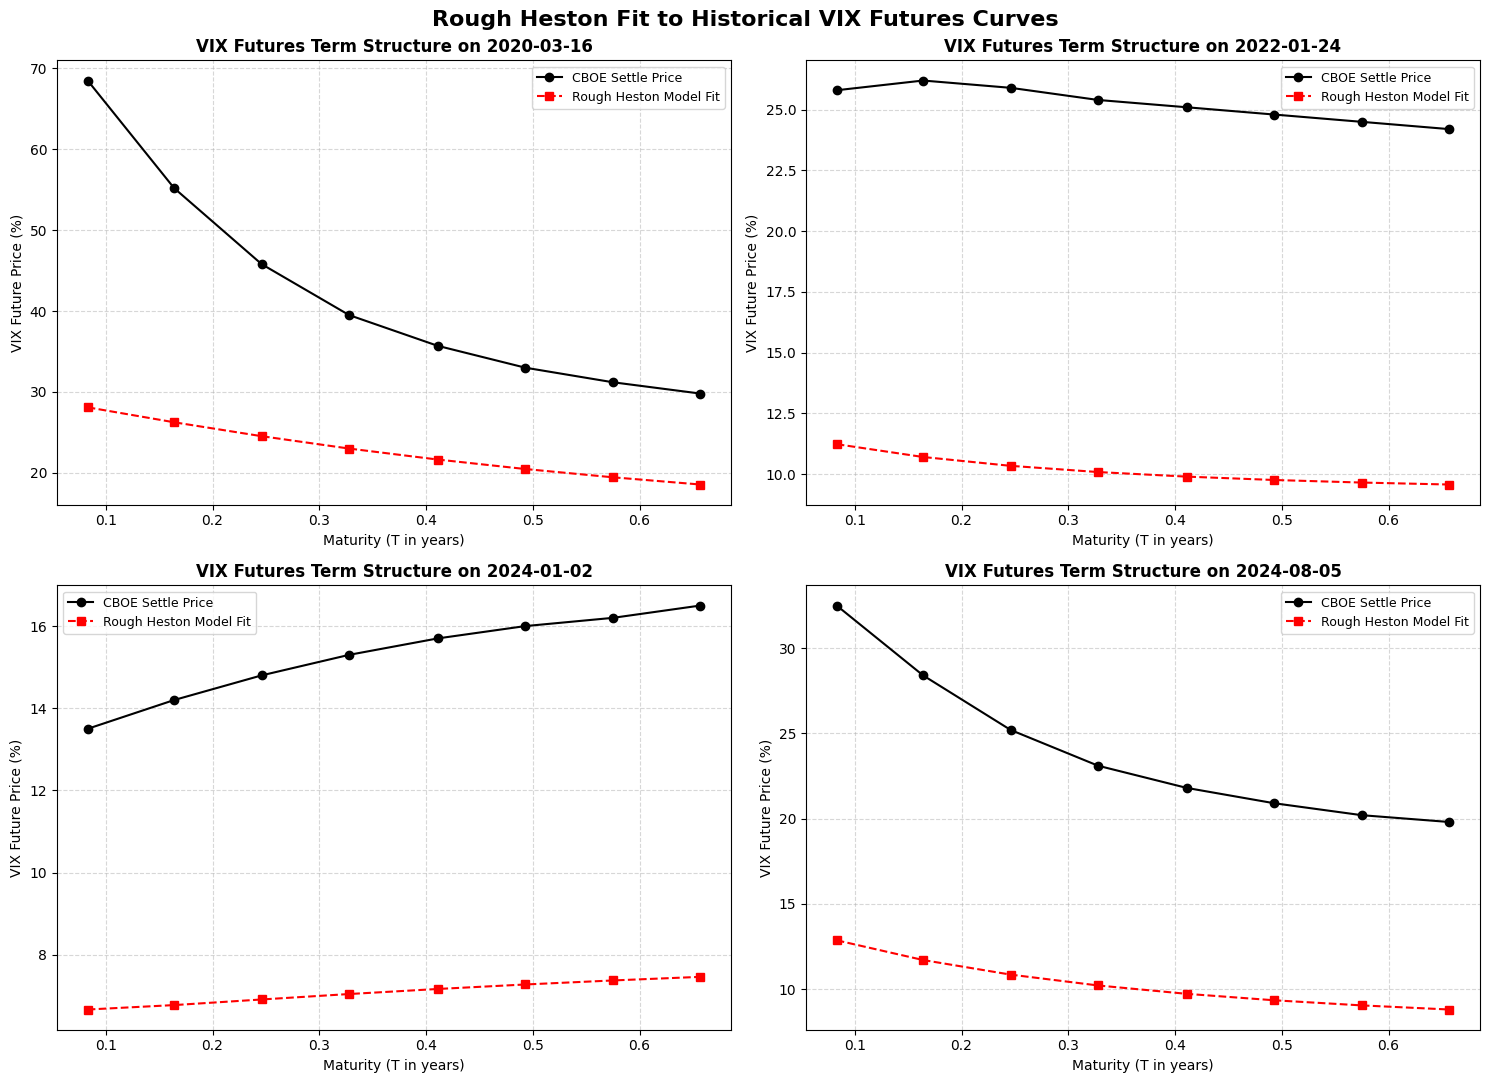

In [5]:
# Compare Model against Historical CBOE VIX Futures
dates = ["2020-03-16", "2022-01-24", "2024-01-02", "2024-08-05"]
params_dict = {
    "2020-03-16": {"kappa": 1.2, "theta": 0.085, "sigma": 1.3, "rho": -0.4, "v0": 0.61, "H": 0.08},
    "2022-01-24": {"kappa": 1.5, "theta": 0.055, "sigma": 0.8, "rho": -0.34, "v0": 0.08, "H": 0.08},
    "2024-01-02": {"kappa": 1.6, "theta": 0.045, "sigma": 0.8, "rho": -0.34, "v0": 0.016, "H": 0.08},
    "2024-08-05": {"kappa": 1.8, "theta": 0.038, "sigma": 1.0, "rho": -0.34, "v0": 0.13, "H": 0.08}
}

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, dt in enumerate(dates):
    hist = download_vix_futures(dt)
    mats = np.array(hist["maturities"])
    observed = np.array(hist["prices"])
    
    p = params_dict[dt]
    pred = vix_futures_curve(p["kappa"], p["theta"], p["sigma"], p["rho"], p["v0"], p["H"], mats)
    
    ax = axes[i]
    ax.plot(mats, observed, 'o-', color='black', label='CBOE Settle Price', markersize=6, lw=1.5)
    ax.plot(mats, pred, 's--', color='red', label='Rough Heston Model Fit', markersize=6, lw=1.5)
    ax.set_title(f"VIX Futures Term Structure on {dt}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Maturity (T in years)", fontsize=10)
    ax.set_ylabel("VIX Future Price (%)", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=9)

plt.suptitle("Rough Heston Fit to Historical VIX Futures Curves", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 4. Parameter Sensitivity Analysis

We examine the sensitivity of the VIX futures curve to variations in:
- $\kappa$ (mean-reversion speed)
- $\theta$ (long-term variance level)
- $v_0$ (initial variance)

<>:11: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
<>:11: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
/tmp/ipykernel_21164/3518994982.py:11: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
  ax.set_title("Sensitivity to Mean Reversion Speed $\kappa$", fontsize=12, fontweight='bold')


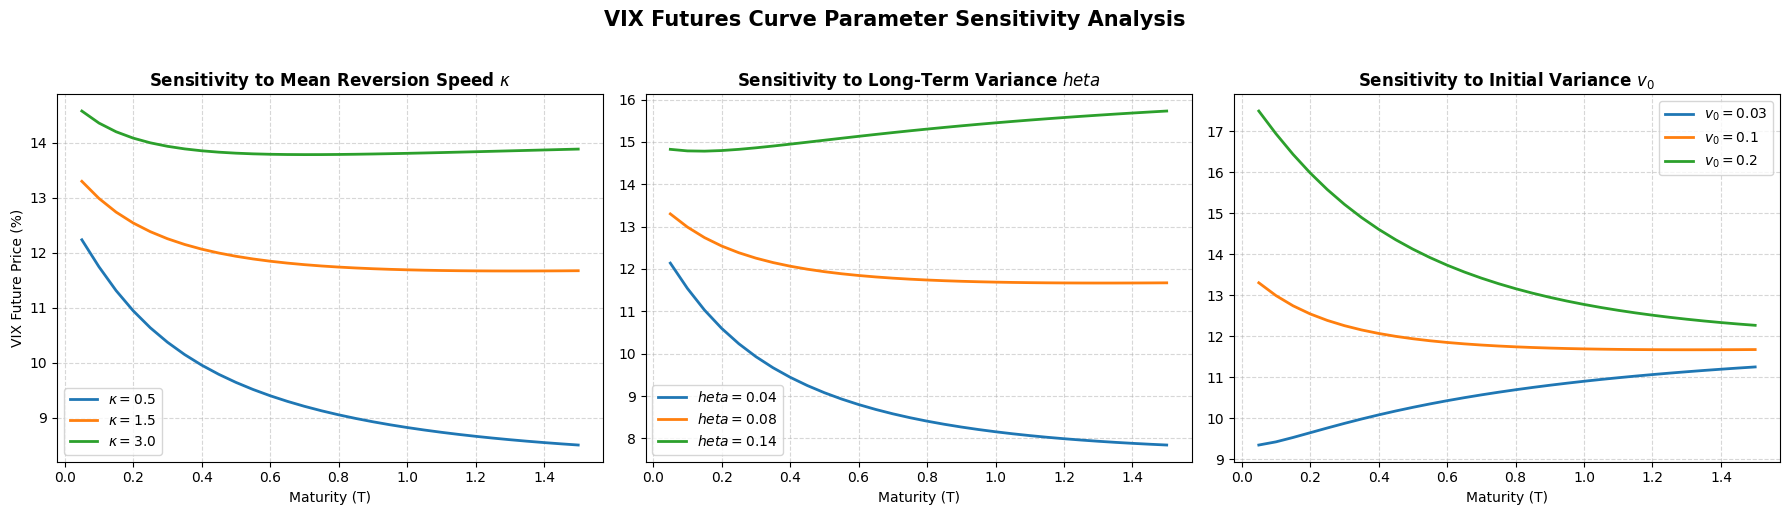

In [6]:
base_params = {"kappa": 1.5, "theta": 0.08, "sigma": 0.8, "rho": -0.34, "v0": 0.10, "H": 0.08}
maturities = np.linspace(0.05, 1.5, 30)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Sensitivity to kappa
ax = axes[0]
for k in [0.5, 1.5, 3.0]:
    curve = vix_futures_curve(k, base_params["theta"], base_params["sigma"], base_params["rho"], base_params["v0"], base_params["H"], maturities)
    ax.plot(maturities, curve, label=f"$\\kappa = {k}$", lw=2)
ax.set_title("Sensitivity to Mean Reversion Speed $\kappa$", fontsize=12, fontweight='bold')
ax.set_xlabel("Maturity (T)")
ax.set_ylabel("VIX Future Price (%)")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

# 2. Sensitivity to theta
ax = axes[1]
for th in [0.04, 0.08, 0.14]:
    curve = vix_futures_curve(base_params["kappa"], th, base_params["sigma"], base_params["rho"], base_params["v0"], base_params["H"], maturities)
    ax.plot(maturities, curve, label=f"$\theta = {th}$", lw=2)
ax.set_title("Sensitivity to Long-Term Variance $\theta$", fontsize=12, fontweight='bold')
ax.set_xlabel("Maturity (T)")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

# 3. Sensitivity to v0
ax = axes[2]
for v in [0.03, 0.10, 0.20]:
    curve = vix_futures_curve(base_params["kappa"], base_params["theta"], base_params["sigma"], base_params["rho"], v, base_params["H"], maturities)
    ax.plot(maturities, curve, label=f"$v_0 = {v}$", lw=2)
ax.set_title("Sensitivity to Initial Variance $v_0$", fontsize=12, fontweight='bold')
ax.set_xlabel("Maturity (T)")
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

plt.suptitle("VIX Futures Curve Parameter Sensitivity Analysis", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Joint SPX-VIX Calibration

We demonstrate the evaluation of the joint loss function `joint_calibration_loss` on a synthetic SPX IV surface and the VIX futures curve, and visualize a 1D slice of the loss surface.

In [7]:
# Generate true synthetic SPX surface and VIX futures
true_params = np.array([1.2, 0.08, 0.8, -0.34, 0.10, 0.08])
vix_maturities = np.array([0.083, 0.164, 0.246, 0.328, 0.411, 0.493, 0.575, 0.657])

# Generate target (observed) VIX futures using true parameters
vix_observed = vix_futures_curve(*true_params, vix_maturities)

from market.vix_pricing import _get_fno_model
from calibrate import _fno_predict_real_iv, _make_spatial_input
import torch
import calibrate

model, device = _get_fno_model()
T_GRID = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])
K_GRID = np.linspace(-0.5, 0.5, 11)
spatial = _make_spatial_input(T_GRID, K_GRID, device)

p6 = torch.tensor([true_params], dtype=torch.float32, device=device)

# Temporarily patch v1 normalizers to point to v2
orig_v1 = calibrate._NORM_VERSIONS["v1"]
calibrate._NORM_VERSIONS["v1"] = calibrate._NORM_VERSIONS["v2"]
calibrate._param_norm = None
calibrate._iv_norm = None
try:
    with torch.no_grad():
        iv_pred_tensor = _fno_predict_real_iv(model, p6, spatial)
finally:
    calibrate._NORM_VERSIONS["v1"] = orig_v1
    calibrate._param_norm = None
    calibrate._iv_norm = None

spx_iv_observed = iv_pred_tensor.cpu().numpy().squeeze()

print("Synthetic SPX IV Observed Surface shape:", spx_iv_observed.shape)
print("Synthetic VIX Futures Observed:", vix_observed)

/tmp/ipykernel_21164/4030858425.py:18: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  p6 = torch.tensor([true_params], dtype=torch.float32, device=device)


Synthetic SPX IV Observed Surface shape: (8, 11)
Synthetic VIX Futures Observed: [12.76923975 12.3034501  11.96871169 11.72764175 11.54799139 11.41468442
 11.31285048 11.23422882]


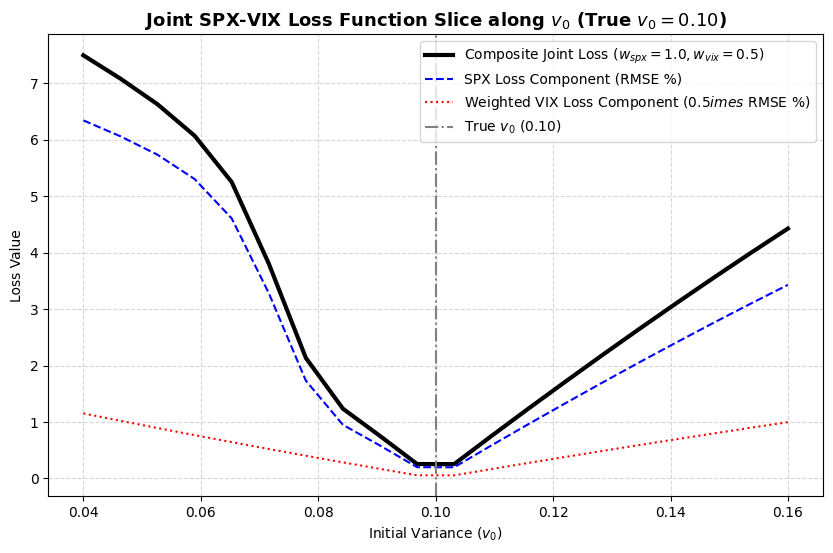

In [8]:
# Perturb v0 and evaluate loss
v0_grid = np.linspace(0.04, 0.16, 20)
losses = []
spx_losses = []
vix_losses = []

for v in v0_grid:
    candidate_params = np.array([1.2, 0.08, 0.8, -0.34, v, 0.08])
    p6_cand = torch.tensor([candidate_params], dtype=torch.float32, device=device)
    
    orig_v1 = calibrate._NORM_VERSIONS["v1"]
    calibrate._NORM_VERSIONS["v1"] = calibrate._NORM_VERSIONS["v2"]
    calibrate._param_norm = None
    calibrate._iv_norm = None
    try:
        with torch.no_grad():
            iv_pred_cand = _fno_predict_real_iv(model, p6_cand, spatial).cpu().numpy().squeeze()
    finally:
        calibrate._NORM_VERSIONS["v1"] = orig_v1
        calibrate._param_norm = None
        calibrate._iv_norm = None
        
    rmse_spx = np.sqrt(np.mean((iv_pred_cand - spx_iv_observed)**2)) * 100.0
    
    vix_pred_cand = vix_futures_curve(*candidate_params, vix_maturities)
    rmse_vix = np.sqrt(np.mean((vix_pred_cand - vix_observed)**2))
    
    composite_loss = joint_calibration_loss(candidate_params, spx_iv_observed, vix_observed, vix_maturities)
    
    losses.append(composite_loss)
    spx_losses.append(rmse_spx)
    vix_losses.append(rmse_vix)

# Plotting the loss surface slice
plt.figure(figsize=(10, 6))
plt.plot(v0_grid, losses, label='Composite Joint Loss ($w_{spx}=1.0, w_{vix}=0.5$)', color='black', lw=3)
plt.plot(v0_grid, np.array(spx_losses), '--', label='SPX Loss Component (RMSE %)', color='blue', lw=1.5)
plt.plot(v0_grid, np.array(vix_losses) * 0.5, ':', label='Weighted VIX Loss Component ($0.5 \times$ RMSE %)', color='red', lw=1.5)
plt.axvline(x=0.10, color='gray', linestyle='-.', label='True $v_0$ (0.10)')
plt.xlabel('Initial Variance ($v_0$)')
plt.ylabel('Loss Value')
plt.title('Joint SPX-VIX Loss Function Slice along $v_0$ (True $v_0=0.10$)', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()